In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from canari import (
    DataProcess,
    Model,
    SKF,
    plot_data,
    plot_prediction,
    plot_skf_states,
)
from canari.component import LocalTrend, LocalAcceleration, Chronos, WhiteNoise
import json
from prophet import Prophet
import numpy as np


In [31]:
benchmark = "4"

In [32]:
# # Read data
path = "/Users/vuongdai/GitHub/canari/"
with open(path + "examples/benchmark/BM_metadata.json", "r") as f:
    metadata = json.load(f)

config = metadata[benchmark]
data_file = path + config["data_path"]

In [33]:
df = pd.read_csv(data_file, skiprows=0, delimiter=",", usecols=[0, 1])
date_time = pd.to_datetime(df["date"])
df = df.drop("date", axis=1)
df.index = date_time
df.index.name = "date_time"
# Data pre-processing
output_col = config["output_col"]
data_processor = DataProcess(
    data=df,
    train_split=0.3,
    validation_split=0.7,
    output_col=output_col,
)
train_data, validation_data, test_data, all_data = data_processor.get_splits()

In [34]:
# Components
sigma_v = 0.08
context_len = 200

local_trend = LocalTrend()
local_acceleration = LocalAcceleration()
chronos = Chronos(
        look_back_len=context_len,
    )
noise = WhiteNoise(std_error=sigma_v)

# Normal model
model = Model(
    local_trend,
    chronos,
    noise,
)

#  Abnormal model
ab_model = Model(
    local_acceleration,
    chronos,
    noise,
)

In [35]:
# --- Detrend mu_lstm_input using Prophet ---
prophet_df = pd.DataFrame({
    "ds": np.array(train_data["time"]).flatten(),
    "y":  np.array(train_data["y"]).flatten()
})
prophet_df["y"] = prophet_df["y"].interpolate()
prophet_model = Prophet()
prophet_model.fit(prophet_df)
trend = prophet_model.predict(prophet_df[["ds"]])["trend"].values
context = prophet_df["y"] - trend

model.lstm_output_history.mu = np.array(context)[-context_len:].flatten()
model.lstm_output_history.time = train_data["time"][-context_len:]

16:04:32 - cmdstanpy - INFO - Chain [1] start processing
16:04:32 - cmdstanpy - INFO - Chain [1] done processing


In [36]:
trend[0]

-1.1400198483485078

In [37]:
# Switching Kalman filter
skf = SKF(
    norm_model=model,
    abnorm_model=ab_model,
    std_transition_error=1e-4,
    norm_to_abnorm_prob=1e-5,
    abnorm_to_norm_prob=0.2,
)
skf.auto_initialize_baseline_states(validation_data["y"][0:52])

In [38]:
# # Anomaly Detection
filter_marginal_abnorm_prob, states = skf.filter(data=validation_data)

Text(0.5, 1, 'SKF hidden states')

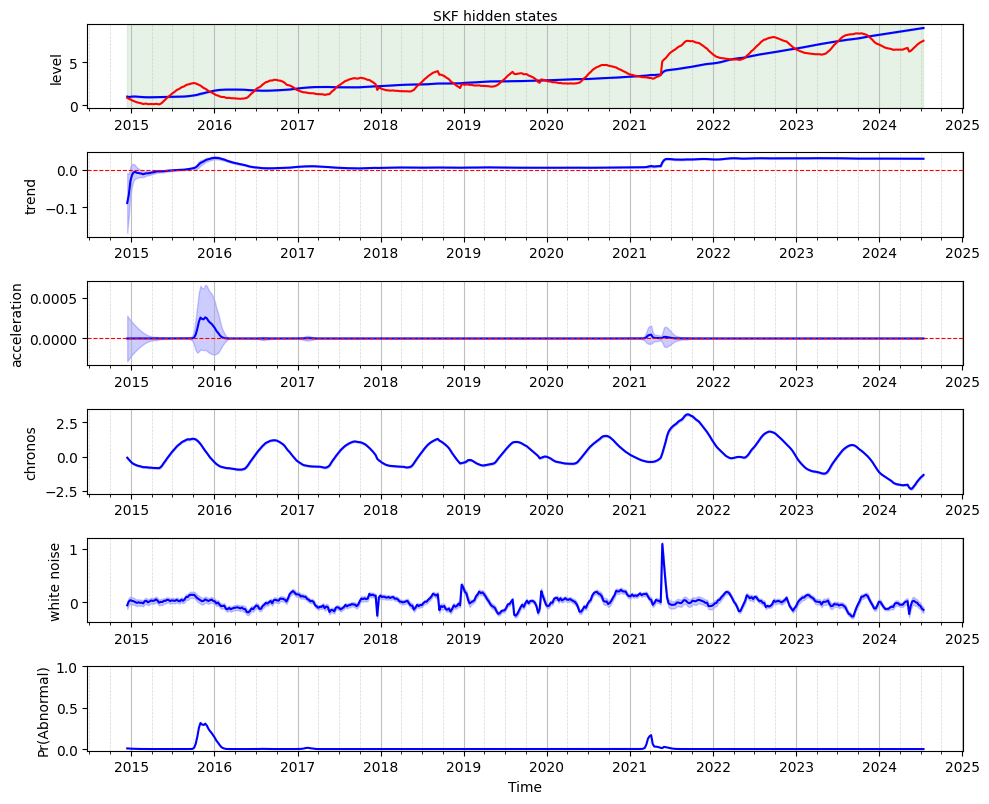

In [39]:
# # Plot
marginal_abnorm_prob_plot = filter_marginal_abnorm_prob

fig, ax = plot_skf_states(
    data_processor=data_processor,
    states=states,
    # states_type="prior",
    model_prob=marginal_abnorm_prob_plot,
    standardization=True,
    color="b",
    plot_observation = True,
    time_start_index = len(train_data["y"]),
)
# ax[0].plot(validation_data["time"], validation_data["y"])
fig.suptitle("SKF hidden states", fontsize=10, y=1)